# Delta-Band Triggered Rolling -- Sandbox

**The problem with static (DTE-only) rolling:** between roll dates, if TSLA crashes, the
10% OTM call drifts toward delta≈0 -- the position goes unhedged. The calendar trigger
doesn't fire for weeks. When TSLA rebounds, the short TSLL position takes the hit with
no call protection left. This is exactly what the 2022 crash data showed.

**The fix tested here:** add a delta-drift trigger. At cycle open, record `entry_delta`.
Each day, recompute `current_delta` from live spot/vol/DTE. If
`|current_delta - entry_delta| > delta_band`, roll early into a fresh contract --
regardless of how many DTE are left.

**Base config:** 10% OTM / 90-day target DTE / roll@5d calendar fallback -- the
Pareto-optimal from the production grid (Sharpe 1.02, Max DD -20.5%).

**Sweep:** `delta_band` in [None (static baseline), 0.10, 0.15, 0.20, 0.25, 0.30].  
Full period only. Single results table + equity/drawdown plot. Nothing else.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve().parents[1]  # scripts/utils/ -> project root
sys.path.insert(0, str(ROOT / "scripts" / "eda"))
sys.path.insert(0, str(ROOT / "scripts" / "backtest"))

from data_loader import load_tsla_underlying, load_tsll, load_tsla_calls
from options_selection import select_contract, bs_delta
from metrics import summarize

%matplotlib inline

tsll        = load_tsll()
r_tsll      = tsll.set_index("Date")["Close"].pct_change().dropna()
returns     = r_tsll.rename("TSLL").to_frame()

tsla_spot   = load_tsla_underlying().set_index("Date")["Close"].reindex(returns.index).ffill()
tsla_calls  = load_tsla_calls()
price_lut   = tsla_calls.set_index(["raw_id", "date"])["px_last"].to_dict()

r_tsla      = tsla_spot.pct_change()
sigma_s     = (r_tsla.rolling(21).std() * (252 ** 0.5)).ffill().bfill()

print(f"{len(returns):,} trading days  {returns.index.min().date()} -> {returns.index.max().date()}")
print("Data loaded.")

962 trading days  2022-08-10 -> 2026-06-10
Data loaded.


In [2]:
# Config -- fixed base, only delta_band varies
BUCKET           = "10% OTM"
FALLBACK_BUCKET  = "ATM"        # if no 10%OTM fill available
TARGET_DTE       = 90
MAX_DTE          = 110
ROLL_DTE         = 5            # calendar safety net
TSLL_LEVER       = 2.0
R_RF             = 0.05

DELTA_BANDS = [None, 0.10, 0.15, 0.20, 0.25, 0.30]
# None  = static calendar-only roll (baseline)
# 0.10  = tight -- roll whenever delta moves 0.10 away from entry
# 0.30  = loose -- only roll on very large drift

print(f"bucket={BUCKET}  target_dte={TARGET_DTE}  calendar_fallback_roll_dte={ROLL_DTE}")
print(f"delta_bands: {DELTA_BANDS}")

bucket=10% OTM  target_dte=90  calendar_fallback_roll_dte=5
delta_bands: [None, 0.1, 0.15, 0.2, 0.25, 0.3]


In [3]:
def simulate_delta_band(returns, calls, spot, sigma_s, delta_band=None):
    """
    Short $1 TSLL (fixed notional, never reset) + long 10%OTM TSLA call, delta-neutral.

    Roll when EITHER:
      (a) held DTE <= ROLL_DTE  -- calendar safety net, same as production
      (b) |current_delta - entry_delta| > delta_band  -- drift trigger (if delta_band is set)

    delta_band=None disables the drift trigger (pure static/calendar baseline).

    Returns: (equity series, n_early_rolls, n_unhedged_days)
    """
    cum_tsll    = (1 + returns["TSLL"]).cumprod()
    base_equity = 2.0 - cum_tsll   # short TSLL P&L

    equity      = pd.Series(index=returns.index, dtype=float)
    position    = None   # dict: {raw_id, strike, expiry, n, price, entry_delta}
    option_pnl  = 0.0
    n_early     = 0
    n_unhedged  = 0

    def mtm(pos, d):
        """Mark-to-market price of the held call."""
        if d > pos["expiry"]:
            return max(float(spot.loc[d]) - pos["strike"], 0.0)
        px = price_lut.get((pos["raw_id"], d))
        return float(px) if (px is not None and not pd.isna(px)) else pos["price"]

    def live_delta(pos, d):
        """Recompute BS delta of the held call at today's market conditions."""
        S     = float(spot.loc[d])
        sigma = float(sigma_s.loc[d]) if d in sigma_s.index else 0.5
        T     = max((pos["expiry"] - d).days / 365.25, 1 / 365.25)  # floor at 1 day
        return bs_delta(S, pos["strike"], T, R_RF, sigma)

    def open_position(d):
        """Select best available contract and return a position dict, or None."""
        for bucket in [BUCKET, FALLBACK_BUCKET]:
            row = select_contract(calls, spot, d, bucket, TARGET_DTE, max_dte=MAX_DTE)
            if row is not None:
                S     = float(spot.loc[d])
                sigma = float(sigma_s.loc[d]) if d in sigma_s.index else 0.5
                T     = (row["expiry"] - d).days / 365.25
                delta = bs_delta(S, float(row["strike"]), T, R_RF, sigma)
                short_dollar_delta = TSLL_LEVER * float(cum_tsll.loc[d])
                n     = short_dollar_delta / (max(delta, 0.01) * 100 * S)
                return {"raw_id": row["raw_id"], "strike": float(row["strike"]),
                        "expiry": row["expiry"], "n": n,
                        "price": float(row["px_last"]), "entry_delta": delta}
        return None

    for d in returns.index:
        held_dte = (position["expiry"] - d).days if position is not None else -1

        # --- decide whether to roll ---
        calendar_roll = position is None or held_dte < ROLL_DTE
        drift_roll    = False
        if not calendar_roll and delta_band is not None:
            if abs(live_delta(position, d) - position["entry_delta"]) > delta_band:
                drift_roll = True

        need_roll = calendar_roll or drift_roll

        if need_roll:
            # close existing
            if position is not None:
                option_pnl += position["n"] * 100 * (mtm(position, d) - position["price"])
                if drift_roll:
                    n_early += 1
            # open new
            position = open_position(d)
            if position is None:
                n_unhedged += 1
        else:
            # hold: mark to market
            px = mtm(position, d)
            option_pnl     += position["n"] * 100 * (px - position["price"])
            position["price"] = px

        equity.loc[d] = base_equity.loc[d] + option_pnl

    return equity, n_early, n_unhedged

In [4]:
rows   = []
curves = {}

for band in DELTA_BANDS:
    label = "static (baseline)" if band is None else f"delta_band={band:.2f}"
    eq, n_early, n_unhedged = simulate_delta_band(returns, tsla_calls, tsla_spot, sigma_s, delta_band=band)
    eq = eq / eq.iloc[0]
    assert eq.isna().sum() == 0, f"{label}: equity has NaNs"
    curves[label] = eq
    row = summarize(eq, eq.pct_change().dropna(), label)
    row["Early rolls"]   = n_early
    row["Unhedged days"] = n_unhedged
    rows.append(row)
    print(f"{label:30s}  CAGR={row['CAGR']:.1%}  Sharpe={row['Sharpe']:.2f}  "
          f"MaxDD={row['Max DD']:.1%}  EarlyRolls={n_early}")

results_df = pd.DataFrame(rows)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", None)
print()
print(results_df[["Strategy", "CAGR", "Ann. Vol", "Sharpe", "Max DD", "Calmar",
                  "Early rolls", "Unhedged days"]].to_string(index=False))

static (baseline)               CAGR=-36.0%  Sharpe=-0.67  MaxDD=-90.7%  EarlyRolls=0


delta_band=0.10                 CAGR=-21.1%  Sharpe=-0.52  MaxDD=-66.0%  EarlyRolls=157
delta_band=0.15                 CAGR=-29.7%  Sharpe=-0.67  MaxDD=-79.0%  EarlyRolls=83


delta_band=0.20                 CAGR=-18.8%  Sharpe=-0.53  MaxDD=-62.9%  EarlyRolls=58
delta_band=0.25                 CAGR=-4.4%  Sharpe=-0.01  MaxDD=-42.5%  EarlyRolls=50
delta_band=0.30                 CAGR=-7.8%  Sharpe=-0.14  MaxDD=-49.1%  EarlyRolls=33

         Strategy      CAGR  Ann. Vol    Sharpe    Max DD    Calmar  Early rolls  Unhedged days
static (baseline) -0.360328  0.491954 -0.668255 -0.906625 -0.397439            0              0
  delta_band=0.10 -0.210616  0.342351 -0.521220 -0.660373 -0.318935          157              0
  delta_band=0.15 -0.296526  0.404814 -0.670517 -0.790382 -0.375167           83              0
  delta_band=0.20 -0.188237  0.306696 -0.528325 -0.629263 -0.299140           58              0
  delta_band=0.25 -0.043586  0.285790 -0.013197 -0.425262 -0.102492           50              0
  delta_band=0.30 -0.078420  0.287189 -0.143442 -0.490989 -0.159718           33              0


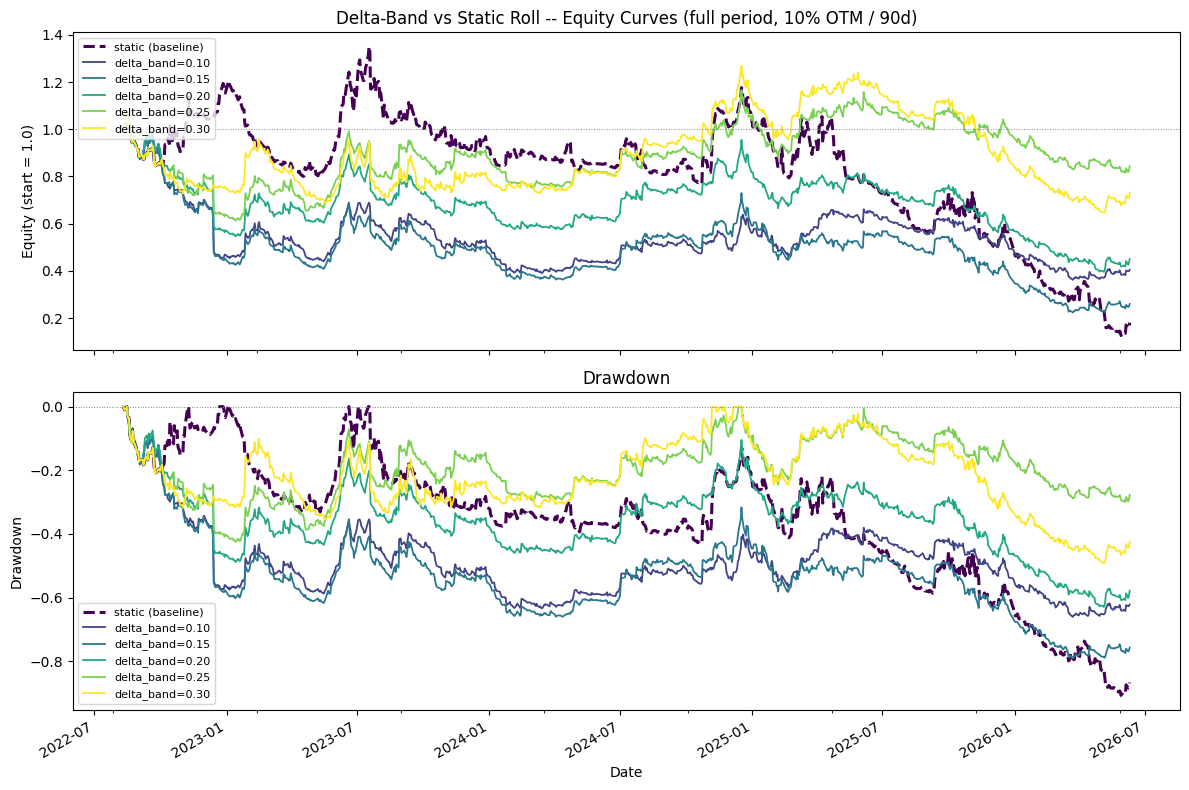

Saved: observations/strategies/sandbox/delta_band_comparison.png


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

import matplotlib.cm as cm
colors = cm.viridis([i / max(len(curves) - 1, 1) for i in range(len(curves))])

for (label, eq), color in zip(curves.items(), colors):
    lw = 2.2 if "baseline" in label else 1.3
    ls = "--"  if "baseline" in label else "-"
    eq.plot(ax=axes[0], label=label, color=color, linewidth=lw, linestyle=ls)
    (eq / eq.cummax() - 1).plot(ax=axes[1], label=label, color=color, linewidth=lw, linestyle=ls)

axes[0].axhline(1.0, color="grey", linestyle=":", linewidth=0.7)
axes[0].set_title("Delta-Band vs Static Roll -- Equity Curves (full period, 10% OTM / 90d)")
axes[0].set_ylabel("Equity (start = 1.0)")
axes[0].legend(fontsize=8, loc="upper left")

axes[1].axhline(0.0, color="grey", linestyle=":", linewidth=0.7)
axes[1].set_title("Drawdown")
axes[1].set_ylabel("Drawdown")
axes[1].legend(fontsize=8, loc="lower left")

fig.tight_layout()
out = ROOT / "observations" / "strategies" / "sandbox" / "delta_band_comparison.png"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out.relative_to(ROOT)}")